# Snapget-12 — train model xác minh ảnh cho AI Daily Quest

Notebook **mỏng**: mọi logic nằm trong `ml/snapget12/` + `ml/scripts/` của repo (để review/diff được). Chạy trên **Google Colab (GPU T4)** hoặc Kaggle. Xem `Snapget/.claude/QUEST_AI_PLAN.md` mục 3–5 và `ml/README.md`.

**Trình tự:** 0 cài đặt → 1 tải COCO subset → 2 cache embedding → 3 train head v0 → 4 chọn ngưỡng + đánh giá → 5 export ONNX int8 → **upload lên Space** → (M6) 6 fine-tune v1 → 8 đánh giá v1 + Snapget-12 → 7 ablation OWL-ViT.

> ⚠️ Runtime → Change runtime type → **T4 GPU** trước khi chạy. Bước 1 tải ~7–9GB về disk Colab (không về máy). Mount Drive để giữ `data/embeddings.npz` + `artifacts/` qua các phiên.

In [1]:
# 0a. Mount Drive (giữ cache embedding + artifact qua các phiên Colab)
from google.colab import drive
drive.mount('/content/drive')
WORK = '/content/drive/MyDrive/snapget-ml'   # đổi nếu muốn
import os; os.makedirs(WORK, exist_ok=True)

Mounted at /content/drive


In [2]:
# 0b. Lấy code từ repo (đổi URL/branch cho đúng) + cài thư viện
%cd /content
!rm -rf datn && git clone --depth 1 https://github.com/HuyenVt001/datn.git datn
%cd /content/datn/ml
!pip install -q -r requirements.txt
!python -c "import torch, torchvision, fiftyone; print(torch.__version__, torch.cuda.is_available())"

/content
Cloning into 'datn'...
remote: Enumerating objects: 741, done.
remote: Counting objects: 100% (741/741), done.
remote: Compressing objects: 100% (649/649), done.
remote: Total 741 (delta 63), reused 460 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (741/741), 30.83 MiB | 20.12 MiB/s, done.
Resolving deltas: 100% (63/63), done.
/content/datn/ml
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 104.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

In [3]:
# 0c. Trỏ data/artifacts vào Drive (symlink) để không mất khi Colab reset
!mkdir -p {WORK}/data {WORK}/artifacts
!ln -sfn {WORK}/data data && ln -sfn {WORK}/artifacts artifacts
!ls -la

total 40
drwxr-xr-x  6 root root 4096 Aug 18 06:44 .
drwxr-xr-x 10 root root 4096 Aug 18 06:42 ..
drwxr-xr-x  3 root root 4096 Aug 18 06:42 ai-service
lrwxrwxrwx  1 root root   43 Aug 18 06:44 artifacts -> /content/drive/MyDrive/snapget-ml/artifacts
lrwxrwxrwx  1 root root   38 Aug 18 06:44 data -> /content/drive/MyDrive/snapget-ml/data
-rw-r--r--  1 root root  163 Aug 18 06:42 .gitignore
drwxr-xr-x  2 root root 4096 Aug 18 06:42 notebooks
-rw-r--r--  1 root root 6026 Aug 18 06:42 README.md
-rw-r--r--  1 root root  361 Aug 18 06:42 requirements.txt
drwxr-xr-x  2 root root 4096 Aug 18 06:42 scripts
drwxr-xr-x  2 root root 4096 Aug 18 06:42 snapget12


## 1. Tải COCO 2017 subset (12 lớp + negative) → `data/manifest.csv`
Chỉ chạy lần đầu (~20–40 phút tuỳ mạng). Giảm `--max-per-class`/`--negatives` nếu hết disk.

In [4]:
!python scripts/01_prepare_coco.py --out data/manifest.csv --max-per-class 4000 --negatives 12000 --test-max 5000
!head -3 data/manifest.csv && wc -l data/manifest.csv


Extracting annotations to '/root/fiftyone/coco-2017/raw/instances_train2017.json'

Writing annotations for 4000 downloaded samples to '/root/fiftyone/coco-2017/train/labels.json'
Dataset info written to '/root/fiftyone/coco-2017/info.json'
Loading 'coco-2017' split 'train'

Dataset 'coco-train-pos-42' created
[train] cup: +4000 -> tong 4000 anh
Found annotations at '/root/fiftyone/coco-2017/raw/instances_train2017.json'
1303 images found; downloading the remaining 2697

Writing annotations for 6697 downloaded samples to '/root/fiftyone/coco-2017/train/labels.json'
Dataset info written to '/root/fiftyone/coco-2017/info.json'
Loading existing dataset 'coco-train-pos-42'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use
[train] bottle: +4000 -> tong 4000 anh
Found annotations at '/root/fiftyone/coco-2017/raw/instances_train2017.json'
770 images found; downloading the remaining 3230

Writing annotations for 9927 downloaded samples to '/root

## 2. Cache embedding backbone

In [5]:
!python scripts/02_cache_embeddings.py --manifest data/manifest.csv --out data/embeddings.npz --batch 128

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth
100% 9.83M/9.83M [00:00<00:00, 121MB/s]
embed[cuda]:   0% 0/46 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that 

## 3. Train head **v0** từ cache (~1–2 phút)

In [6]:
!python scripts/03_train_head.py --emb data/embeddings.npz --out artifacts/v0/head.pt --epochs 30

train 3600 / val 400 embedding
pos_weight: {'cup': 0.0, 'bottle': 2.04, 'book': 7.33, 'chair': 2.21, 'potted plant': 11.29, 'laptop': 10.01, 'keyboard': 17.0, 'backpack': 31.14, 'clock': 19.81, 'umbrella': 49.7, 'bicycle': 86.8, 'motorcycle': 256.14}
epoch  1 loss 1.0675  val mAP 0.4005
epoch  2 loss 0.8867  val mAP 0.4169
epoch  3 loss 0.8032  val mAP 0.4305
epoch  4 loss 0.7755  val mAP 0.4395
epoch  5 loss 0.7496  val mAP 0.4399
epoch  6 loss 0.7195  val mAP 0.4419
epoch  7 loss 0.7066  val mAP 0.441
epoch  8 loss 0.6850  val mAP 0.442
epoch  9 loss 0.6687  val mAP 0.4444
epoch 10 loss 0.6620  val mAP 0.4461
epoch 11 loss 0.6472  val mAP 0.4424
epoch 12 loss 0.6462  val mAP 0.4469
epoch 13 loss 0.6325  val mAP 0.4482
epoch 14 loss 0.6233  val mAP 0.4441
epoch 15 loss 0.6194  val mAP 0.4467
epoch 16 loss 0.6105  val mAP 0.4486
epoch 17 loss 0.5948  val mAP 0.4477
epoch 18 loss 0.5954  val mAP 0.4465
epoch 19 loss 0.5908  val mAP 0.4485
epoch 20 loss 0.5845  val mAP 0.4493
epoch 21 lo

## 4. Chọn ngưỡng per-class (precision ≥ 0.8, max recall) + đánh giá COCO val/test + PR curve

thresholds: {'cup': 0.2665, 'bottle': 0.8762, 'book': 0.9239, 'chair': 0.8758, 'potted plant': 0.7515, 'laptop': 0.99, 'keyboard': 0.6163, 'backpack': 0.5629, 'clock': 0.659, 'umbrella': 0.9324, 'bicycle': 0.8856, 'motorcycle': 0.99}
[val] n=400 mAP=0.4511 macroF1=0.3546
   cup            thr=0.267 P=1.000 R=1.000 F1=1.000 AP=1.0 n=400
   bottle         thr=0.876 P=1.000 R=0.009 F1=0.017 AP=0.4809 n=117
   book           thr=0.924 P=1.000 R=0.135 F1=0.237 AP=0.5691 n=52
   chair          thr=0.876 P=0.812 R=0.088 F1=0.159 AP=0.6452 n=148
   potted plant   thr=0.751 P=0.378 R=0.359 F1=0.368 AP=0.2629 n=39
   laptop         thr=0.990 P=0.333 R=0.054 F1=0.093 AP=0.5544 n=37
   keyboard       thr=0.616 P=0.500 R=0.846 F1=0.629 AP=0.4975 n=26
   backpack       thr=0.563 P=0.098 R=0.800 F1=0.174 AP=0.0936 n=10
   clock          thr=0.659 P=0.172 R=0.526 F1=0.260 AP=0.1312 n=19
   umbrella       thr=0.932 P=0.800 R=0.400 F1=0.533 AP=0.5897 n=10
   bicycle        thr=0.886 P=0.400 R=0.222 F1=0

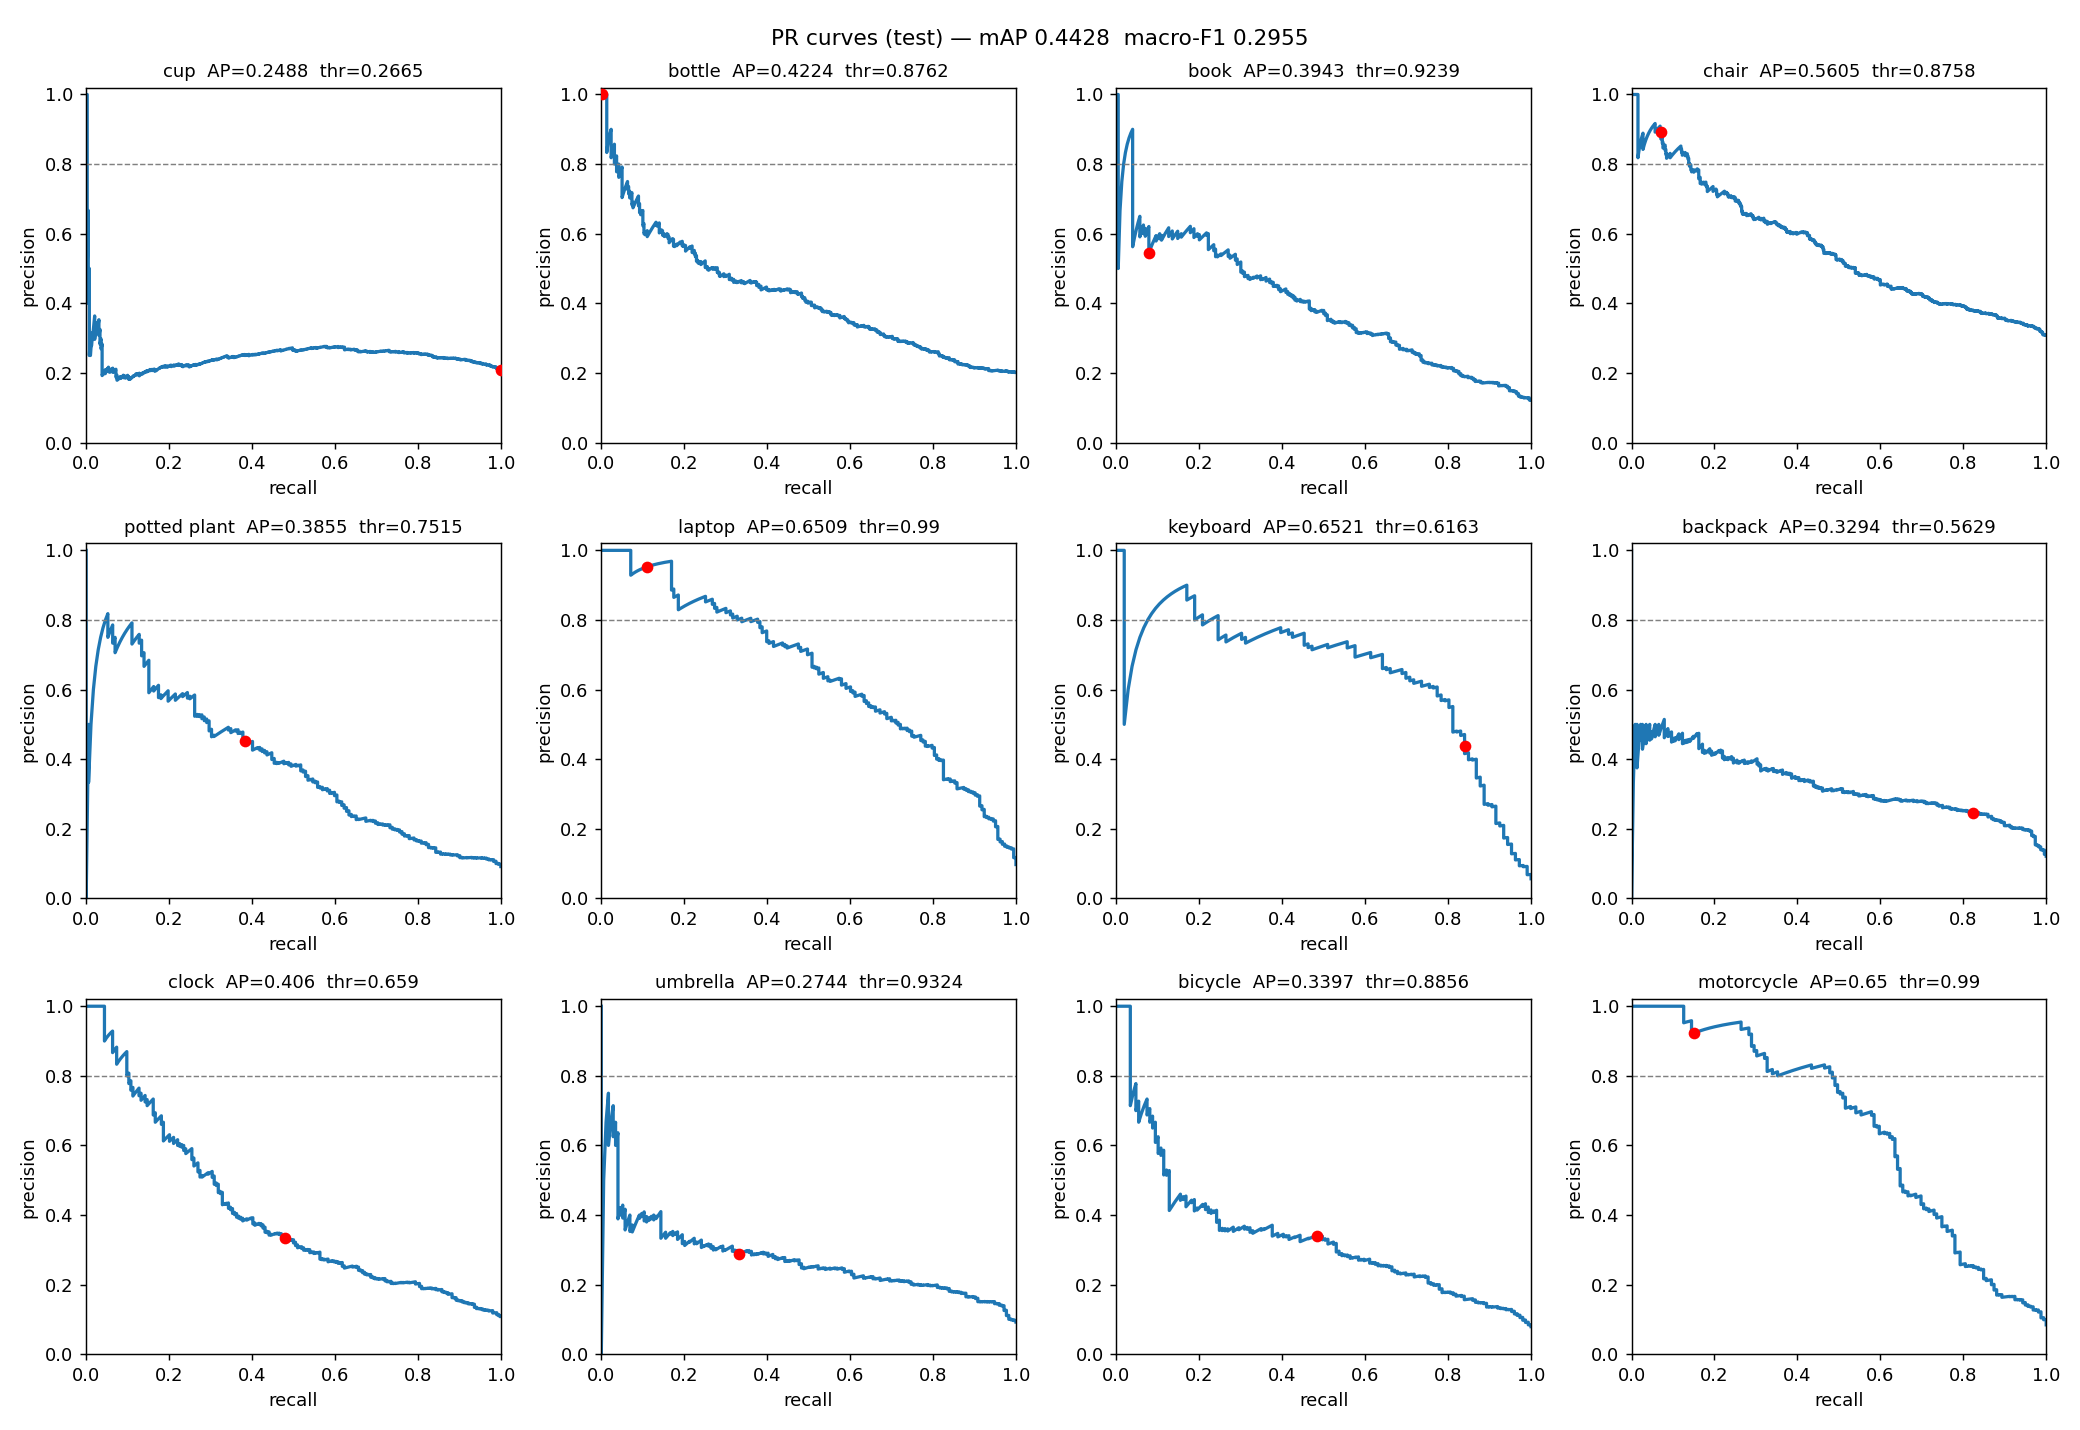

In [7]:
!python scripts/04_eval_thresholds.py --emb data/embeddings.npz --head artifacts/v0/head.pt --out artifacts/v0
from IPython.display import Image, display
display(Image('artifacts/v0/pr_curves_test.png'))

## 5. Export ONNX int8 + `model_meta.json` → **upload lên HF Model repo** (miễn phí)
Cần token HF quyền **write**. Điền `MODEL_REPO` = `<user>/snapget-ai-model`. Sau đó AI service trên **Cloud Run** tự tải model qua env `MODEL_REPO` (QUEST_AI_PLAN mục 17.C5b).

In [12]:
!pip install -q onnxscript

In [26]:
%cd /content/datn
!git pull
%cd /content/datn/ml
!grep -n '"--quant"' scripts/05_export_onnx.py
!rm -f artifacts/v0/model.onnx artifacts/v0/model_fp32.onnx




/content/datn
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 5 (delta 4), reused 5 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 924 bytes | 308.00 KiB/s, done.
From https://github.com/HuyenVt001/datn
   0a5cef4..8e3cca2  main       -> origin/main
Updating 0a5cef4..8e3cca2
Fast-forward
 Snapget/.claude/QUEST_AI_PLAN.md | 2 ++
 1 file changed, 2 insertions(+)
/content/datn/ml
46:    ap.add_argument("--quant", choices=["head", "none", "full"], default="head",


In [24]:
from huggingface_hub import login
login()   # dán token write
MODEL_REPO = 'Flowerng/snapget-ai-model'   # HF MODEL repo (mien phi) — Cloud Run tai tu day
!python scripts/05_export_onnx.py --head artifacts/v0/head.pt --version v0 --out artifacts/v0 --upload {MODEL_REPO}

/content/datn/ml/scripts/05_export_onnx.py:76: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, dummy, str(fp32_path), dynamo=False, **export_kwargs)
max |pytorch_fp32 - onnx_serve| = 0.0064   (quant=dynamic int8 head-only (MatMul))
latency onnx CPU: p50 2.9ms  p95 4.0ms
-> artifacts/v0/model.onnx (3.89 MB), model_meta.json
Processing Files (0 / 0)      : |          |  0.00B /  0.00B            
New Data Upload               : |          |  0.00B /  0.00B            

  ...l/artifacts/v0/model.onnx:   4% 150k/3.89M [00:00<?, ?B/s]

Processing Files (0 / 1)      :   4% 150k/3.89M [00:00<00:12, 298kB/s,   ???B/s  ]

Processing Files (0 

✅ **Tới đây là xong M1+M2 phần model**: deploy/restart Cloud Run với `MODEL_REPO` (plan 17.C5b) rồi `GET <Service URL>/health` phải trả `modelVersion: "v0"`, `verifierReady: true`.

---
## M6 — Snapget-12, fine-tune v1, ablation

### 6a. Upload tập **Snapget-12** tự chụp
Cấu trúc thư mục (zip rồi kéo lên Drive `{WORK}/data/snapget12/`): `snapget12/cup/*.jpg`, `snapget12/bottle/*.jpg`, …, `snapget12/negative/*.jpg`. Ảnh có 2 vật thể → đặt tên `cup+book_01.jpg`. Mỗi lớp ~10 ảnh/thành viên, chụp **bằng chính app/điện thoại** (dọc, trong nhà, đèn vàng…).

In [ ]:
# 6b. Đánh giá model v0 ĐANG CHẠY (ONNX int8) trên Snapget-12 -> domain shift so với COCO test
#     (báo cáo: 3 lớp book/backpack/keyboard dự kiến thấp nhất -> lý do app chỉ ra đề 9 lớp, plan 2.3)
!python scripts/08_eval_images.py --onnx artifacts/v0/model.onnx --thresholds artifacts/v0/thresholds.json \
    --manifest data/manifest.csv --snapget12 data/snapget12 --out artifacts/v0

### 6c. Fine-tune **v1** (mở block conv cuối, augmentation crop dọc 3:4) — ~30–60 phút T4

In [ ]:
!python scripts/06_finetune_v1.py --manifest data/manifest.csv --init-head artifacts/v0/head.pt --out artifacts/v1/model.pt --epochs 8
# chọn ngưỡng trên val + đánh giá test + Snapget-12 (cùng tập với v0 để so sánh delta)
!python scripts/08_eval_images.py --full artifacts/v1/model.pt --manifest data/manifest.csv \
    --choose-thresholds-on val --snapget12 data/snapget12 --out artifacts/v1

### 6d. Export v1 → upload Model repo (thay v0) — chỉ khi v1 tốt hơn trên **Snapget-12** (rồi restart Cloud Run)

In [ ]:
!python scripts/05_export_onnx.py --full artifacts/v1/model.pt --version v1 --out artifacts/v1 --upload {MODEL_REPO}

### 7. Ablation: OWL-ViT zero-shot trên cùng 2 tập test (~150M params, vài giây/ảnh CPU)

In [ ]:
!python scripts/07_ablation_owlvit.py --manifest data/manifest.csv --snapget12 data/snapget12 --out artifacts/owlvit --max-test 1500

### 8. Bảng tổng hợp cho báo cáo

In [ ]:
import json, glob
rows = []
for name in ['v0', 'v1', 'owlvit']:
    for split in ['test', 'snapget12']:
        p = f'artifacts/{name}/metrics_{split}.json'
        try:
            m = json.load(open(p))
            rows.append((name, split, m['n'], m['mAP'], m['macroF1'], m.get('latencyMs')))
        except FileNotFoundError:
            pass
print(f"{'model':8s} {'split':10s} {'n':>6s} {'mAP':>7s} {'macroF1':>8s}  latency")
for r in rows:
    print(f"{r[0]:8s} {r[1]:10s} {r[2]:6d} {r[3]:7.4f} {r[4]:8.4f}  {r[5]}")